In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import glob as glob
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import os
from aux import zero_pad, format_plot, format_pc_plot, add_inset_axes
from csv_reader import read_csv
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.offline as pyo
import subprocess
import cv2
from natsort import natsorted
import seaborn as sns

In [ ]:
def plot_losses(data_paths, xlim=None, ylim=None, thresh=2000):
    for dp in data_paths:
        fig, axs = plt.subplots(1, 2, figsize=(4, 2), sharey=True)

        for i in range(2):
            axs[i].grid(zorder=0, linestyle='--', linewidth=0.5, alpha=0.7)
            axs[i].set_axisbelow(True)
            axs[i].yaxis.set_major_locator(MultipleLocator(1000))  # grid every 1.0 on y-axis
        
        o = read_csv(os.path.join('sims_out', dp, 'train_data.csv'), read_header=False)
        losses = np.array(o.iloc[:, 1])
        axs[0].scatter(np.arange(len(losses)), losses, s=1, c='black', zorder=1)
        axs[0].set_ylim(0, 10000)
        if xlim is not None:
            axs[0].set_xlim(*xlim)
        if ylim is not None:
            axs[0].set_ylim(*ylim)

        o = read_csv(os.path.join('sims_out', dp, 'test_data.csv'), read_header=False)
        x = np.array(o.iloc[:, 0])
        losses_test = np.array(o.iloc[:, 1])
        axs[1].scatter(x, losses_test, s=1, c='black', zorder=1)
        axs[1].set_ylim(0, 10000)
        if xlim is not None:
            axs[1].set_xlim(*xlim)
        if ylim is not None:
            axs[1].set_ylim(*ylim)

        if (losses_test < thresh).any():
            print(dp)

        axs[0].set_ylabel('Loss')
        axs[0].set_xlabel('Epochs')
            
        format_plot(axs)

In [11]:
from matplotlib.ticker import ScalarFormatter

def plot_losses_fig(data_paths, xlim=None, ylim=None, thresh=2000, save_name=None):
    for dp in data_paths:
        fig, axs = plt.subplots(1, 1, figsize=(2, 2), sharey=True)
        axs = np.atleast_1d(axs)

        for i in range(1):
            axs[i].grid(zorder=0, linestyle='--', linewidth=0.5, alpha=0.7)
            axs[i].set_axisbelow(True)

        o = read_csv(os.path.join('sims_out', dp, 'train_data.csv'), read_header=False)
        losses = np.array(o.iloc[:, 1])
        losses_means = [
            np.mean(losses[i:i+30])
            for i in range(0, len(losses) - 30, 30)
        ]
        axs[0].scatter(np.arange(len(losses)), losses, c='black', zorder=1, s=0.5, rasterized=True)

        if xlim is not None:
            axs[0].set_xlim(*xlim)
        if ylim is not None:
            axs[0].set_ylim(*ylim)

        axs[0].set_ylabel('Loss')
        axs[0].set_xlabel('Epochs')

        format_plot(axs)

        for ax in axs:
            ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

        if save_name is not None:
            fig.savefig(save_name + '.svg', bbox_inches='tight')

# 2D results

### 2D network, 300ms integration, no heterogeneity

In [5]:
data_paths = [
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-02_16:46:27.499428_run_000650',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-02_16:46:27.700953_run_000651',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-02_16:46:27.700958_run_000652',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-02_16:46:27.308348_run_000653',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-02_16:46:27.832414_run_000654',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-02_16:46:27.630045_run_000655',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-02_16:46:27.389153_run_000656',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-02_16:46:27.208592_run_000657',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-02_16:46:27.240842_run_000658',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-02_16:46:27.997662_run_000659',
]

    # '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-02_16:46:27.499428_run_000650',
    # '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-02_16:46:27.700953_run_000651',
    # '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-02_16:46:27.700958_run_000652',
    # '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-02_16:46:27.308348_run_000653',
    # '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-02_16:46:27.832414_run_000654',
    # '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-02_16:46:27.630045_run_000655',
    # '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-02_16:46:27.389153_run_000656',
    # '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-02_16:46:27.208592_run_000657',
    # '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-02_16:46:27.240842_run_000658',
    # '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-02_16:46:27.997662_run_000659',

2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-02_16:46:27.700958_run_000652
2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-02_16:46:27.832414_run_000654
2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-02_16:46:27.997662_run_000659


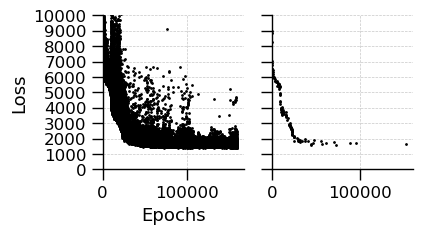

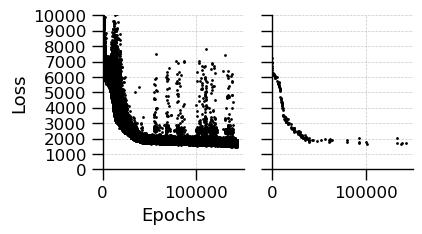

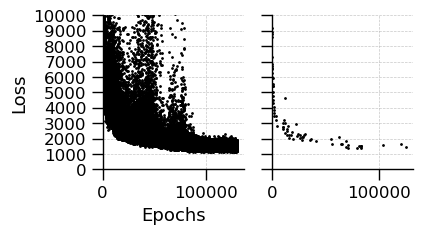

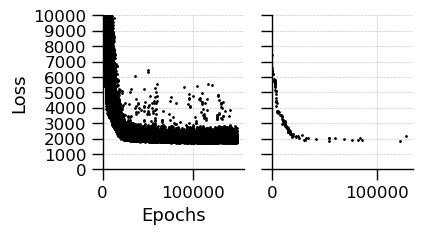

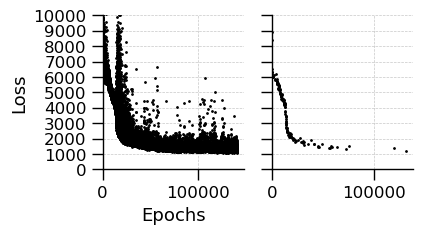

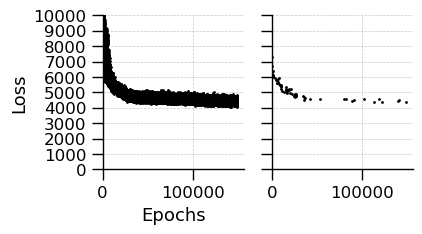

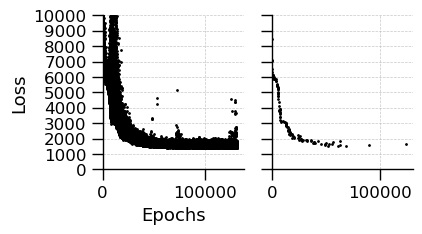

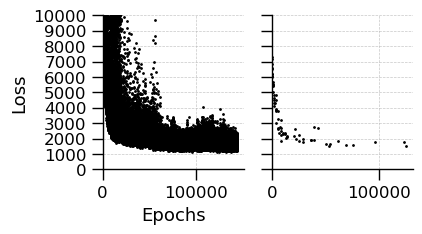

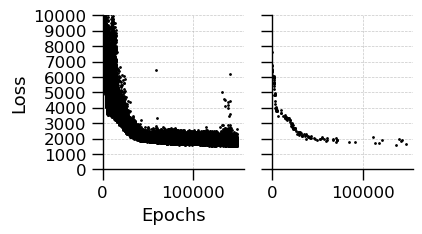

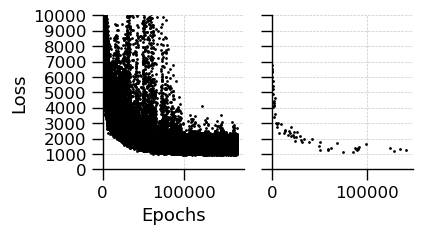

In [6]:
plot_losses(data_paths, xlim=(0, None), thresh=1500)

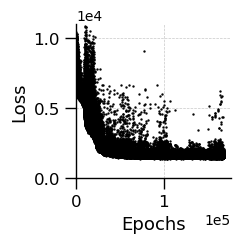

In [12]:
plot_losses_fig(data_paths[:1], xlim=(0, None), ylim=(0, 1.1e4), thresh=2500, save_name='./figures/2d_no_het_short_optim')

### 2D network, 300ms integration, *with* heterogeneity

In [41]:
data_paths = [
    '2D_short_reverted_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-27_11:35:26.491536_run_000560',
    '2D_short_reverted_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-11-27_11:35:18.795081_run_000561',
    '2D_short_reverted_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-11-27_11:35:18.795083_run_000562',
    '2D_short_reverted_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-11-27_11:35:19.145924_run_000563',
    '2D_short_reverted_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-11-27_11:35:18.795069_run_000564',
    '2D_short_reverted_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-11-27_11:35:22.320036_run_000565',
    '2D_short_reverted_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-11-27_11:35:22.320040_run_000566',
    '2D_short_reverted_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-11-27_11:35:22.320039_run_000567',
    '2D_short_reverted_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-11-27_11:35:22.320042_run_000568',
    '2D_short_reverted_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-11-27_11:35:18.554100_run_000569',
]

# Rule with reasonable results 
# 2D_short_reverted_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-11-27_11:35:18.795081_run_000561
# 2D_short_reverted_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-11-27_11:35:18.795083_run_000562
# 2D_short_reverted_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-11-27_11:35:19.145924_run_000563
# 2D_short_reverted_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-11-27_11:35:22.320036_run_000565
# 2D_short_reverted_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-11-27_11:35:22.320040_run_000566
# 2D_short_reverted_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-11-27_11:35:22.320039_run_000567
# 2D_short_reverted_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-11-27_11:35:22.320042_run_000568


2D_short_reverted_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-11-27_11:35:18.795081_run_000561
2D_short_reverted_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-11-27_11:35:22.320042_run_000568


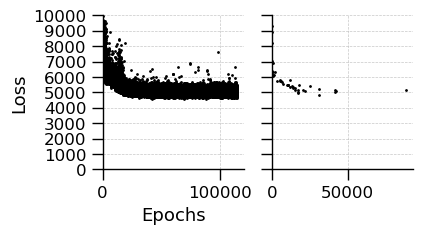

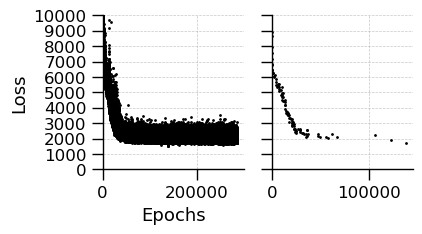

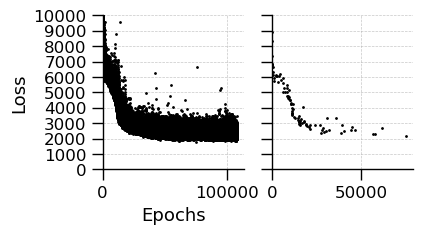

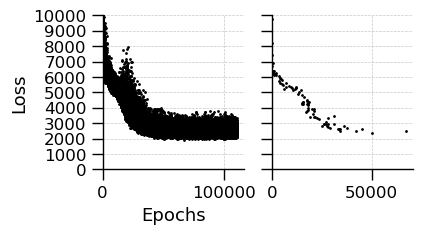

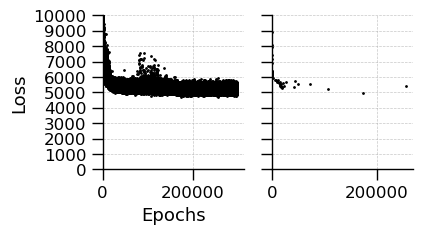

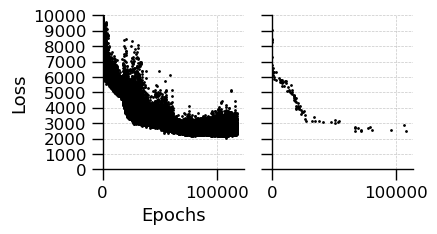

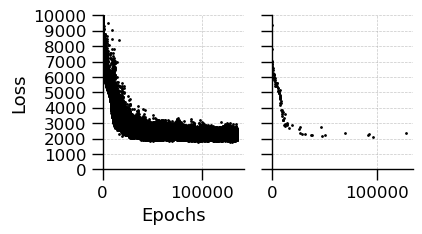

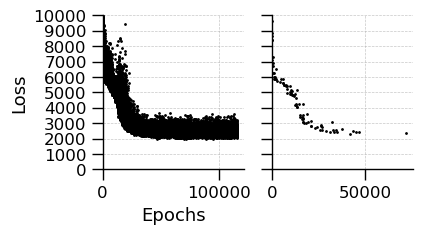

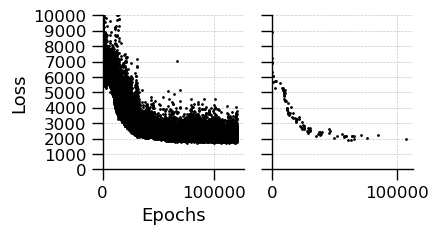

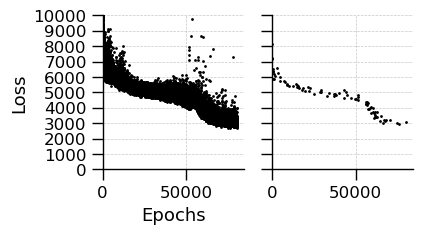

In [42]:
plot_losses(data_paths, xlim=(0, None), thresh=2000)

### 2D network, 1s integration, 300ms input, no heterogeneity

In [7]:
data_paths = [
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-02_16:47:31.663760_run_000660',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-02_16:47:31.450558_run_000661',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-02_16:47:31.663768_run_000662',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-02_16:47:34.681922_run_000663',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-02_16:47:33.386051_run_000664',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-02_16:47:31.398493_run_000665',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-02_16:47:35.775894_run_000666',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-02_16:48:06.688903_run_000667',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-02_16:48:06.477098_run_000668',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-02_16:48:06.495310_run_000669',
]

2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-02_16:47:31.663760_run_000660
2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-02_16:47:31.450558_run_000661
2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-02_16:47:31.663768_run_000662
2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-02_16:47:34.681922_run_000663
2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-02_16:47:33.386051_run_000664
2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-02_16:47:31.398493_run_000665
2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_

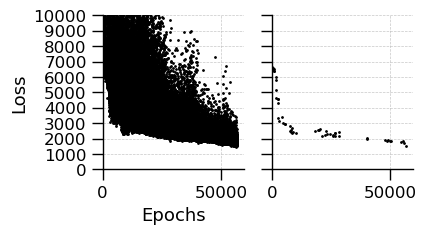

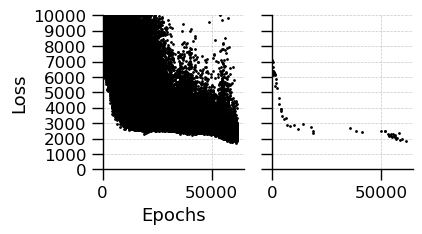

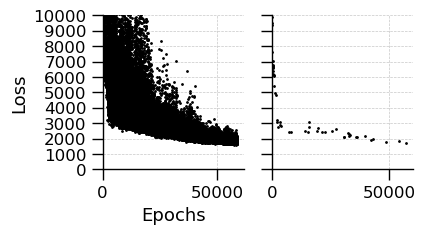

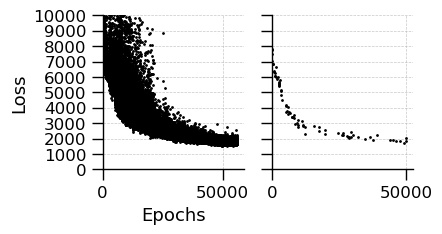

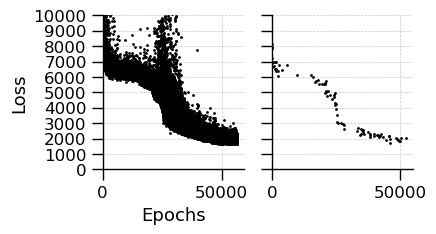

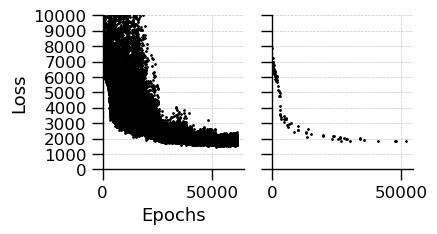

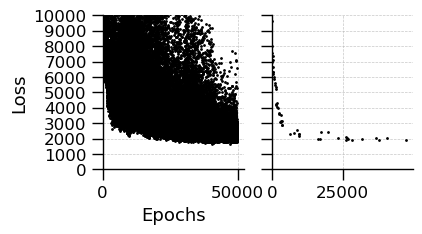

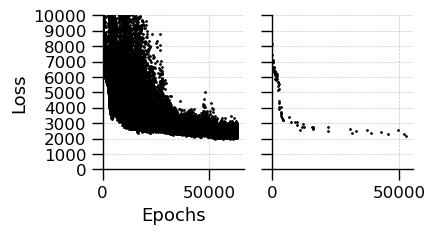

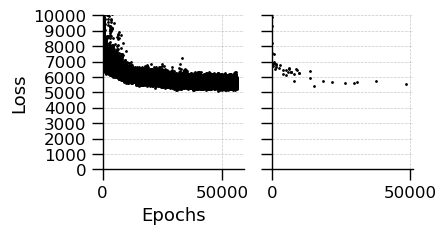

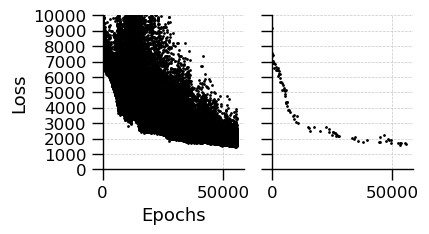

In [8]:
plot_losses(data_paths, xlim=(0, None), thresh=2000)

### 2D network, 1s integration, 300ms input, *with* heterogeneity

In [9]:
data_paths = [
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-30_23:04:35.727347_run_000600',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-11-30_23:04:35.274079_run_000601',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-11-30_23:04:31.169992_run_000602',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-11-30_23:04:31.493962_run_000603',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-11-30_23:04:31.498427_run_000604',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-11-30_23:04:31.368493_run_000605',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-11-30_23:04:31.368496_run_000606',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-11-30_23:04:31.368495_run_000607',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-11-30_23:04:31.480864_run_000608',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-11-30_23:04:32.804142_run_000609',
]

2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-11-30_23:04:31.368496_run_000606
2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-11-30_23:04:31.368495_run_000607


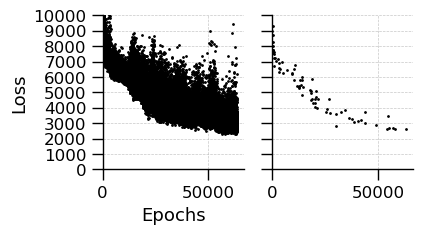

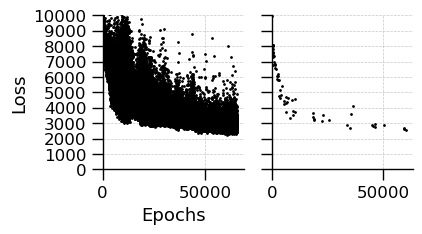

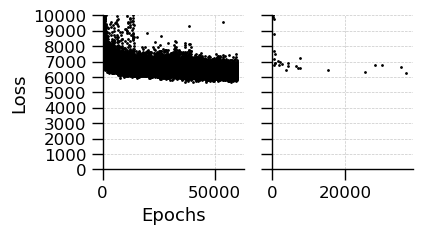

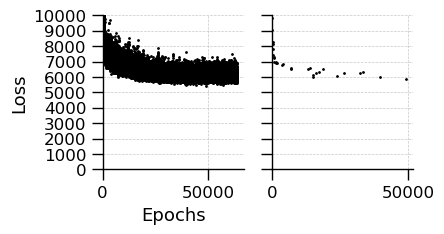

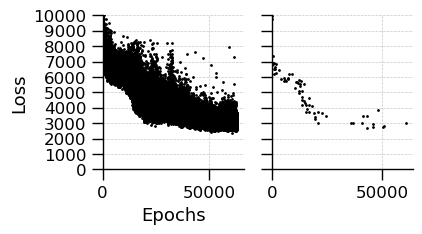

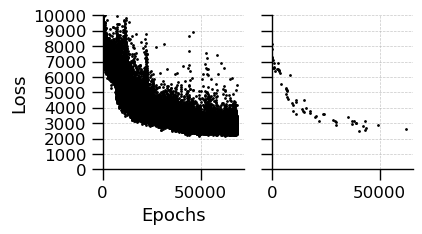

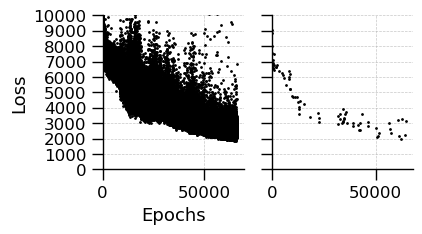

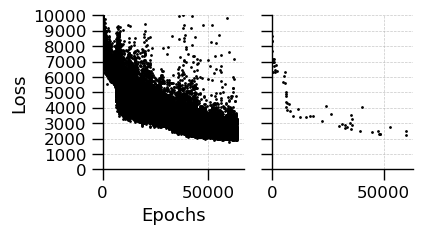

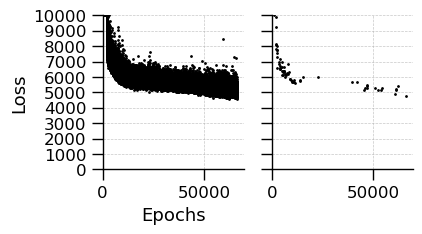

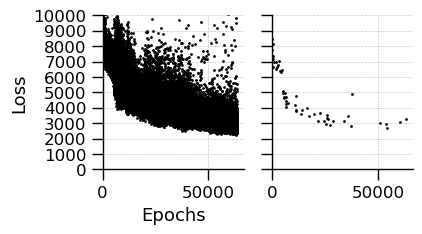

In [10]:
plot_losses(data_paths, xlim=(0, None), thresh=2500)

### 2D network, 1s integration, 1s input, *with* heterogeneity

In [11]:
data_paths = [
    '2D_long_persist_input_reverted_time_1.0_inp_0.97_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-30_23:05:03.275205_run_000610',
    '2D_long_persist_input_reverted_time_1.0_inp_0.97_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-11-30_23:05:03.196701_run_000611',
    '2D_long_persist_input_reverted_time_1.0_inp_0.97_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-11-30_23:05:04.742945_run_000612',
    '2D_long_persist_input_reverted_time_1.0_inp_0.97_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-11-30_23:05:04.742951_run_000613',
    '2D_long_persist_input_reverted_time_1.0_inp_0.97_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-11-30_23:05:04.742947_run_000614',
    '2D_long_persist_input_reverted_time_1.0_inp_0.97_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-11-30_23:05:04.742950_run_000615',
    '2D_long_persist_input_reverted_time_1.0_inp_0.97_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-11-30_23:05:04.742949_run_000616',
    '2D_long_persist_input_reverted_time_1.0_inp_0.97_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-11-30_23:05:06.754783_run_000617',
    '2D_long_persist_input_reverted_time_1.0_inp_0.97_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-11-30_23:05:06.754775_run_000618',
    '2D_long_persist_input_reverted_time_1.0_inp_0.97_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-11-30_23:05:06.754780_run_000619',
]

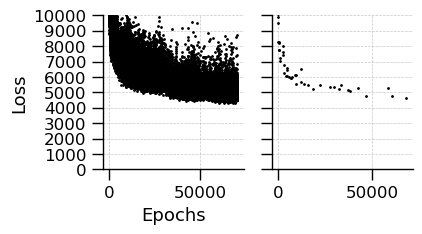

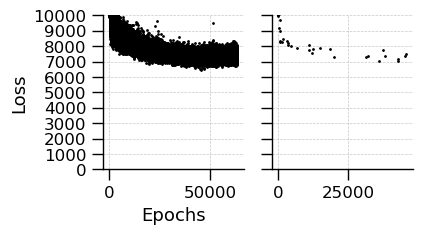

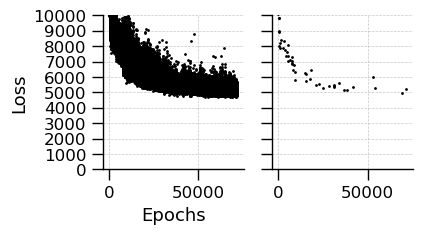

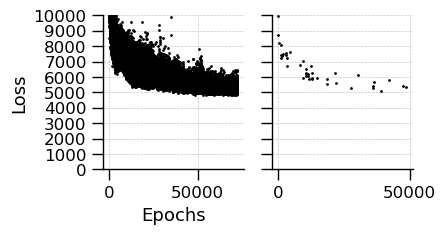

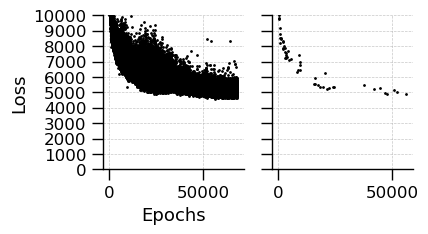

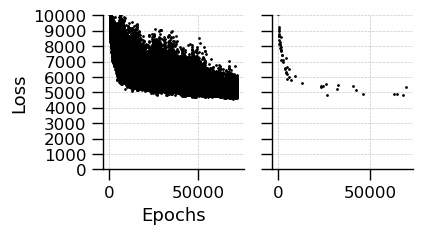

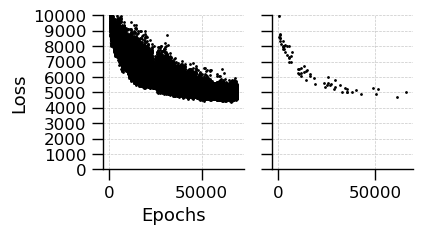

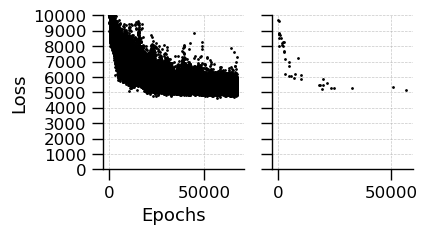

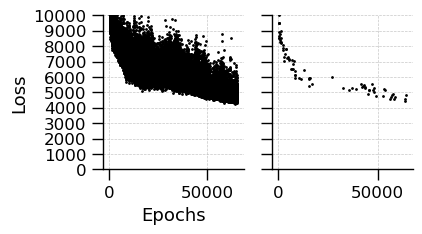

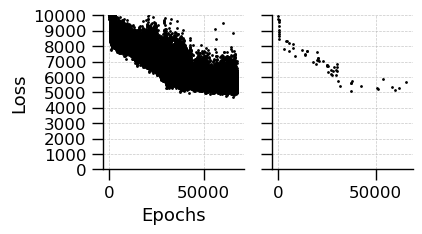

In [12]:
plot_losses(data_paths)

# 5 unit networks

### 5 unit network, 300s integration, 300ms input, *with* heterogeneity

In [13]:
data_paths = [
    'n5_time_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-28_12:22:22.229831_run_000590',
    'n5_time_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-11-28_12:22:22.229829_run_000591',
    'n5_time_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-11-28_12:22:22.229832_run_000592',
    'n5_time_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-11-28_12:22:22.229832_run_000593',
    'n5_time_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-11-28_12:22:19.734933_run_000594',
    'n5_time_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-11-28_12:22:22.561619_run_000595',
    'n5_time_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-11-28_12:22:23.214785_run_000596',
    'n5_time_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-11-28_12:22:23.214780_run_000597',
    'n5_time_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-11-28_12:22:23.463050_run_000598',
    'n5_time_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-11-28_12:22:23.463042_run_000599',
]

# runs that appear to work
# 'n5_time_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-28_12:22:22.229831_run_000590',
# 'n5_time_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-11-28_12:22:22.229829_run_000591',
# 'n5_time_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-11-28_12:22:22.229832_run_000593',
# 'n5_time_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-11-28_12:22:23.214785_run_000596',
# 'n5_time_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-11-28_12:22:23.463042_run_000599',

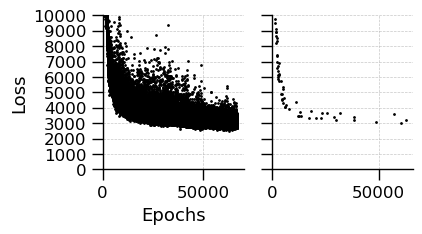

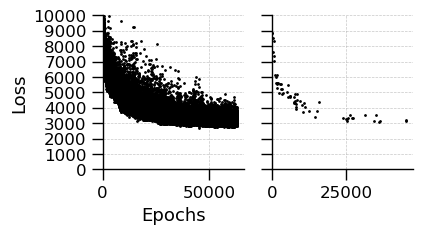

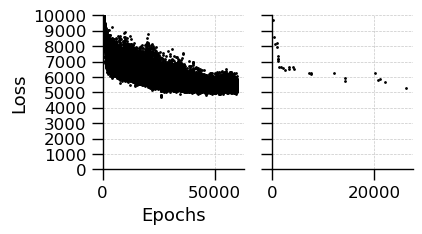

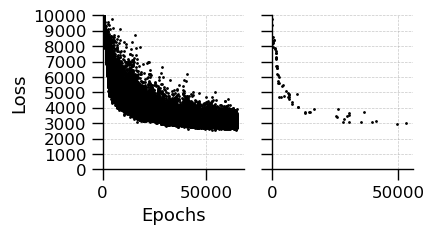

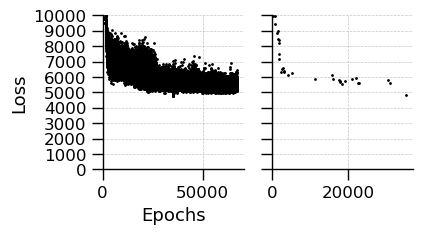

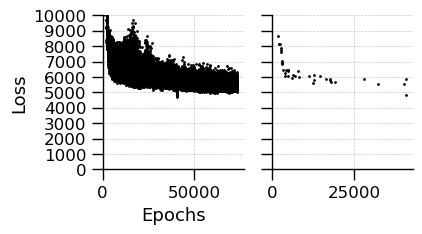

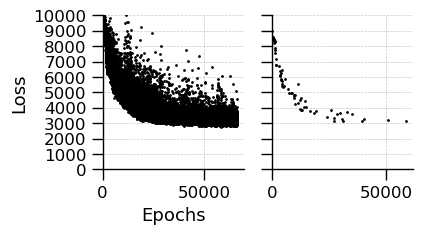

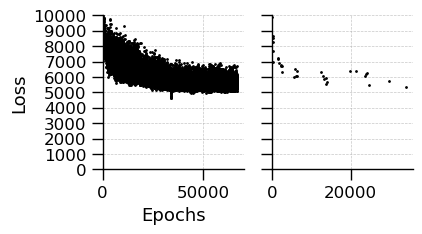

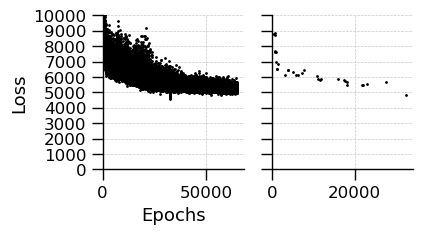

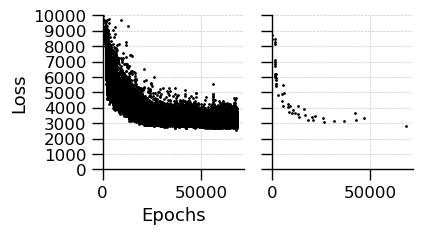

In [14]:
plot_losses(data_paths, xlim=(0, None))

### 5 unit network, 1s integration, 300ms input, *with* heterogeneity

In [15]:
data_paths = [
    'n5_time_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-11-30_23:05:42.589849_run_000620',
    'n5_time_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-11-30_23:06:02.752508_run_000621',
    'n5_time_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-11-30_23:06:02.752503_run_000622',
    'n5_time_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-11-30_23:06:02.752516_run_000623',
    'n5_time_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-11-30_23:06:09.576064_run_000624',
    'n5_time_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-11-30_23:06:09.576072_run_000625',
    'n5_time_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-11-30_23:06:09.576074_run_000626',
    'n5_time_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-11-30_23:06:09.576073_run_000627',
    'n5_time_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-11-30_23:06:09.576071_run_000628',
    'n5_time_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-11-30_23:06:09.576069_run_000629',
]

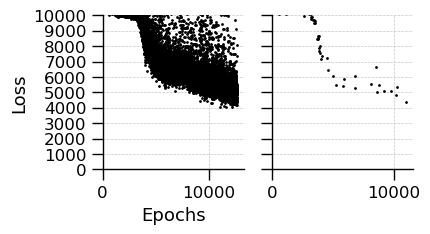

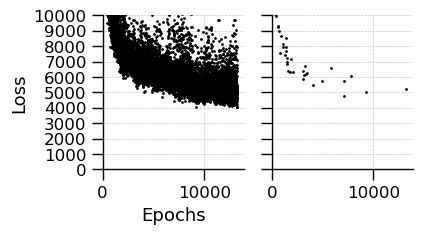

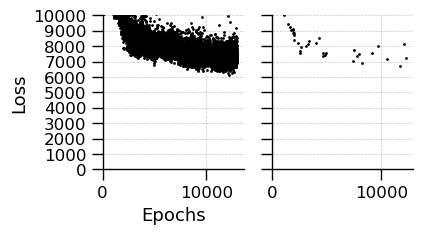

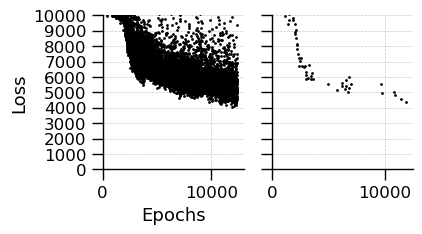

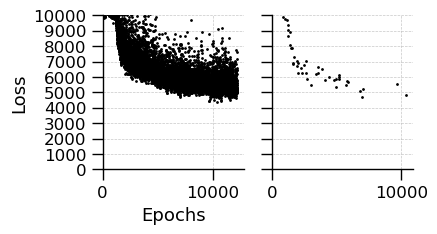

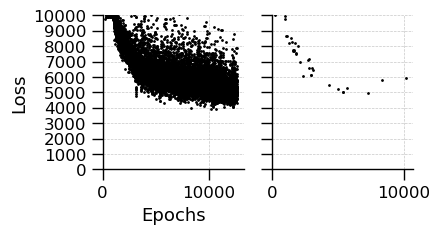

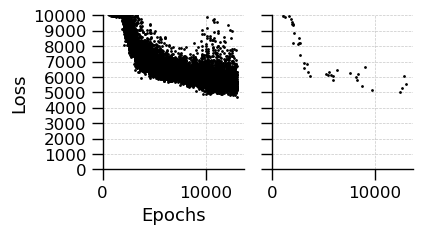

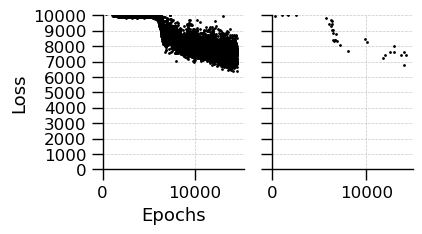

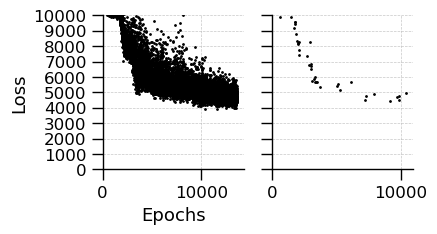

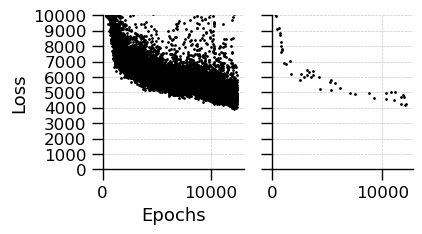

In [16]:
plot_losses(data_paths, xlim=(0, None))

### 5 unit network, 300s integration, 300ms input, *with* heterogeneity
I raised the minimum probably of getting an input at any timestep here from 0.1 to 0.25, so inputs are more frequent across all networks in this version of the task.

In [9]:
data_paths = [
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-02_12:50:11.212162_run_000640',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-02_12:50:15.723738_run_000641',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-02_12:50:15.238381_run_000642',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-02_12:50:11.052374_run_000643',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-02_12:50:15.141691_run_000644',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-02_12:50:15.141693_run_000645',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-02_12:50:50.206678_run_000646',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-02_12:50:50.206680_run_000647',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-02_12:50:50.206680_run_000648',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-02_12:50:50.206677_run_000649',
]

n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-02_12:50:11.052374_run_000643
n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-02_12:50:50.206680_run_000648


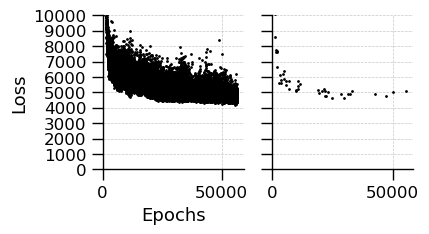

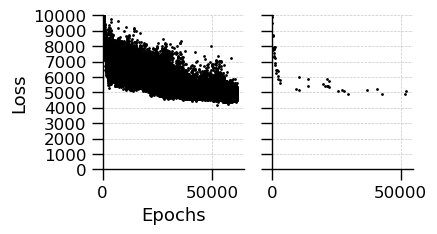

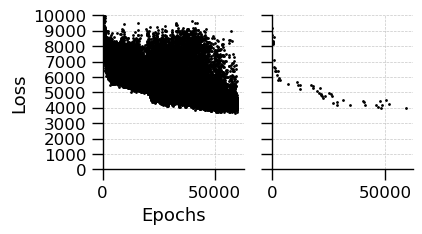

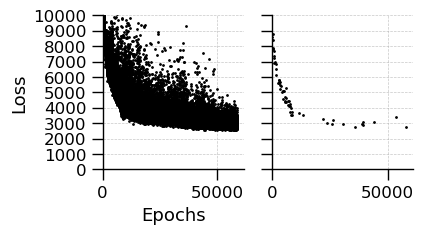

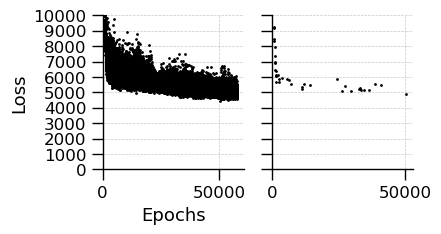

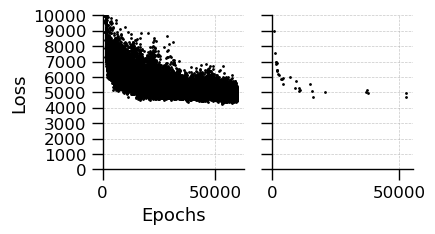

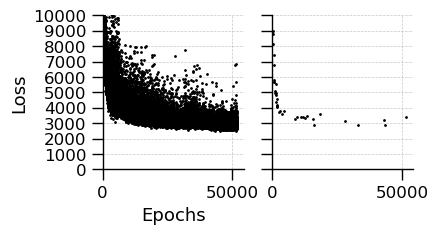

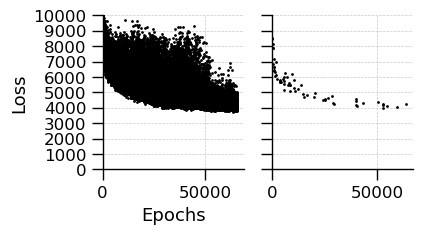

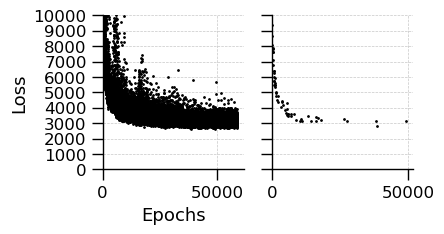

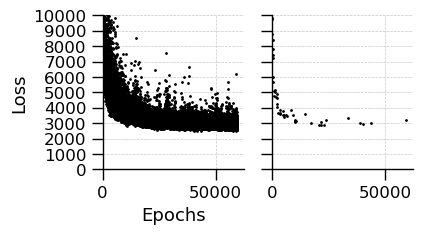

In [10]:
plot_losses(data_paths, xlim=(0, None), thresh=2800)

### 5 unit network, 300ms integration, 300ms input, no heterogeneity

In [13]:
data_paths = [
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-02_16:48:34.109400_run_000670',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-02_16:48:38.316658_run_000671',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-02_16:48:38.316655_run_000672',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-02_16:48:38.316657_run_000673',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-02_16:48:38.316176_run_000674',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-02_16:48:38.316170_run_000675',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-02_16:48:38.318557_run_000676',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-02_16:48:38.318552_run_000677',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-02_16:48:37.677239_run_000678',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-02_16:48:37.881489_run_000679',
]

n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-02_16:48:38.316655_run_000672
n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-02_16:48:38.318552_run_000677
n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-02_16:48:37.677239_run_000678
n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-02_16:48:37.881489_run_000679


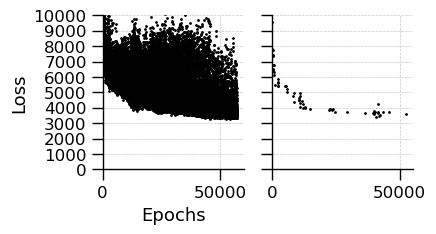

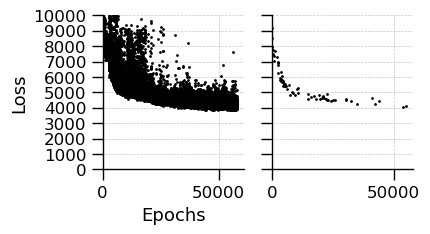

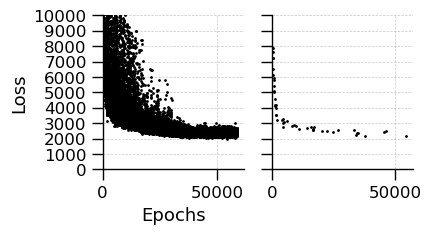

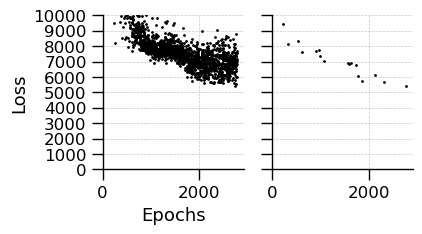

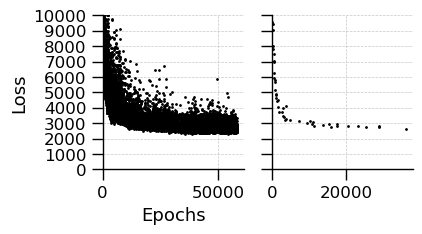

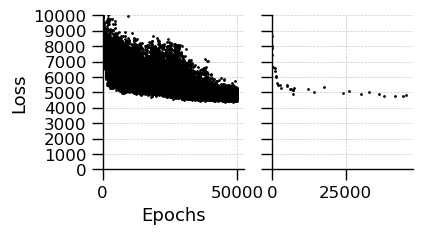

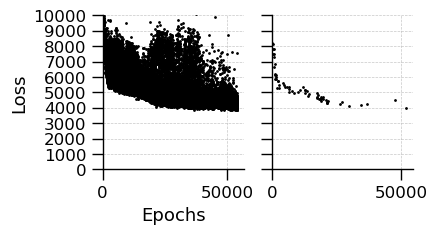

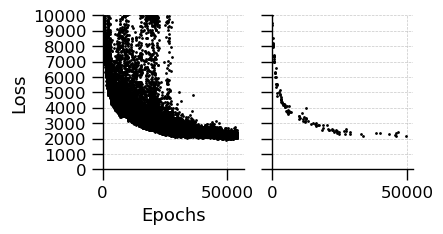

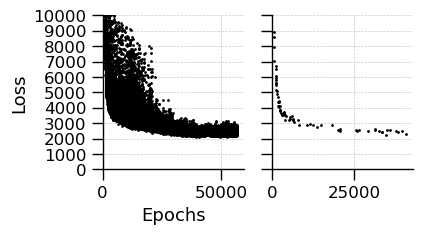

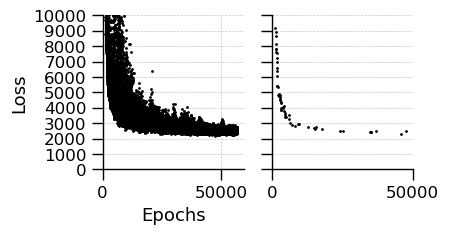

In [14]:
plot_losses(data_paths, xlim=(0, None), thresh=2500)

In [15]:
data_paths = [
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-02_16:50:08.750023_run_000680',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-02_16:50:15.248758_run_000681',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-02_16:50:15.248755_run_000682',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-02_16:50:15.248752_run_000683',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-02_16:50:14.812608_run_000684',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-02_16:50:14.812615_run_000685',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-02_16:50:14.812590_run_000686',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-02_16:50:14.812635_run_000687',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-02_16:50:13.176410_run_000688',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-02_16:50:13.176406_run_000689',
]

n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-02_16:50:15.248752_run_000683


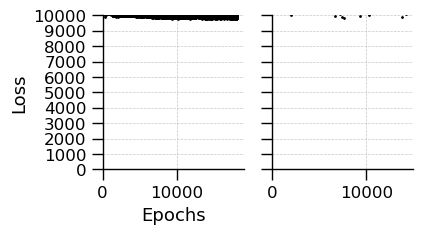

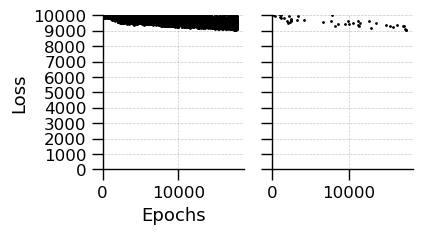

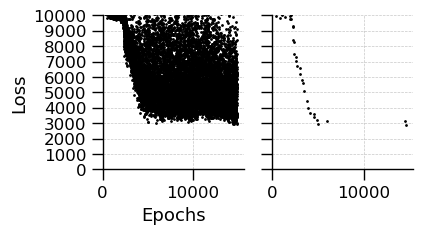

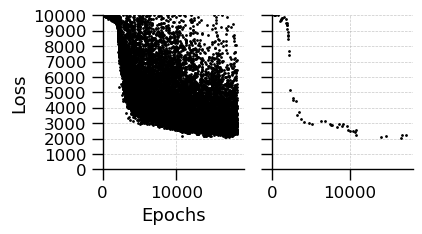

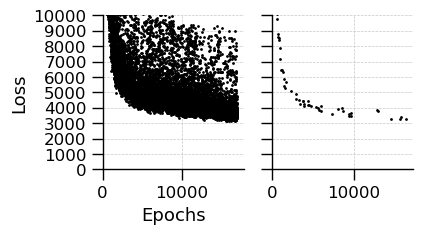

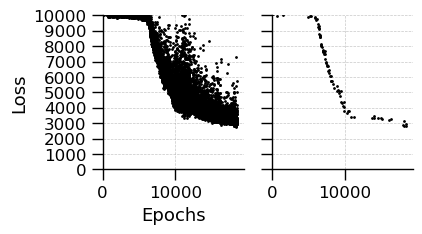

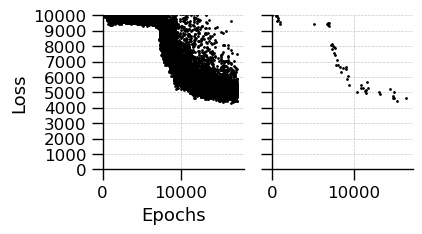

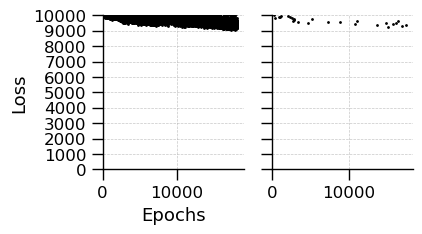

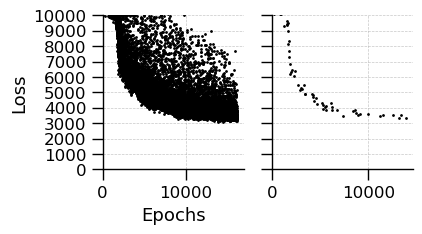

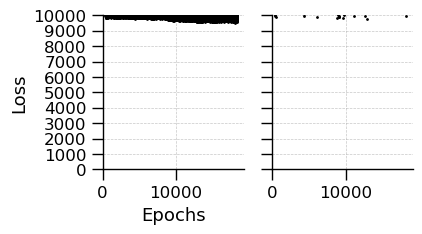

In [16]:
plot_losses(data_paths, xlim=(0, None), thresh=2500)

In [12]:
data_paths = [
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-06_11:06:21.028860_run_000690',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-06_11:06:24.084352_run_000691',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-06_11:06:24.084356_run_000692',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-06_11:06:21.523080_run_000693',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-06_11:06:21.190428_run_000694',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-06_11:06:21.190418_run_000695',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-06_11:06:26.699449_run_000696',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-06_11:06:26.699444_run_000697',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-06_11:06:26.699447_run_000698',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-06_11:06:26.699449_run_000699',
]

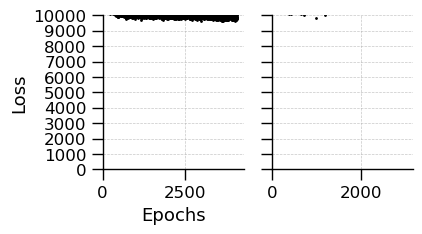

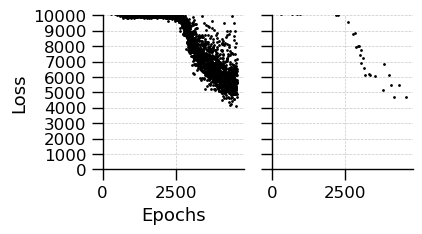

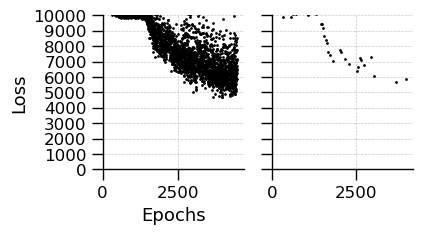

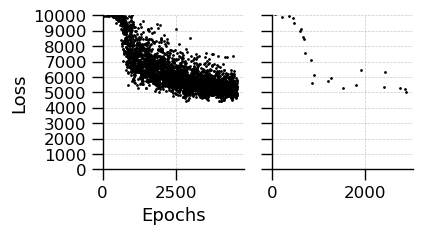

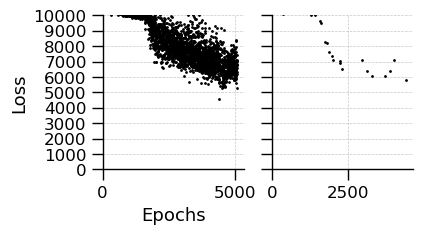

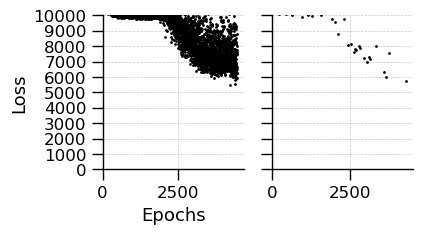

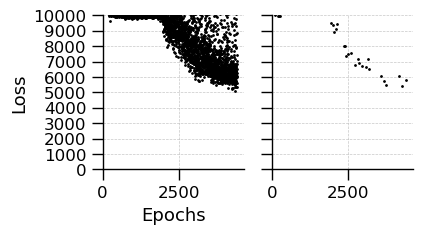

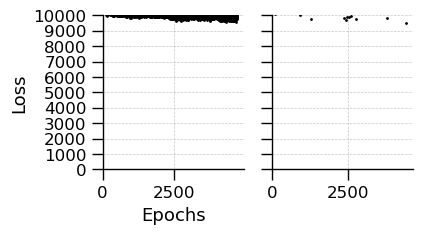

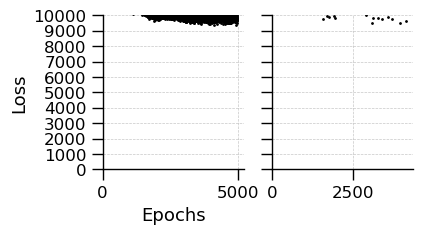

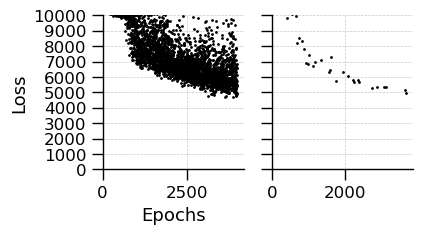

In [14]:
plot_losses(data_paths, xlim=(0, None), thresh=2500)

In [ ]:
plot_losses_fig(data_paths, xlim=(0, None), ylim=(1000, 1.1e4), thresh=2500)

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7fc2a02636a0> (for post_execute), with arguments args (),kwargs {}:
